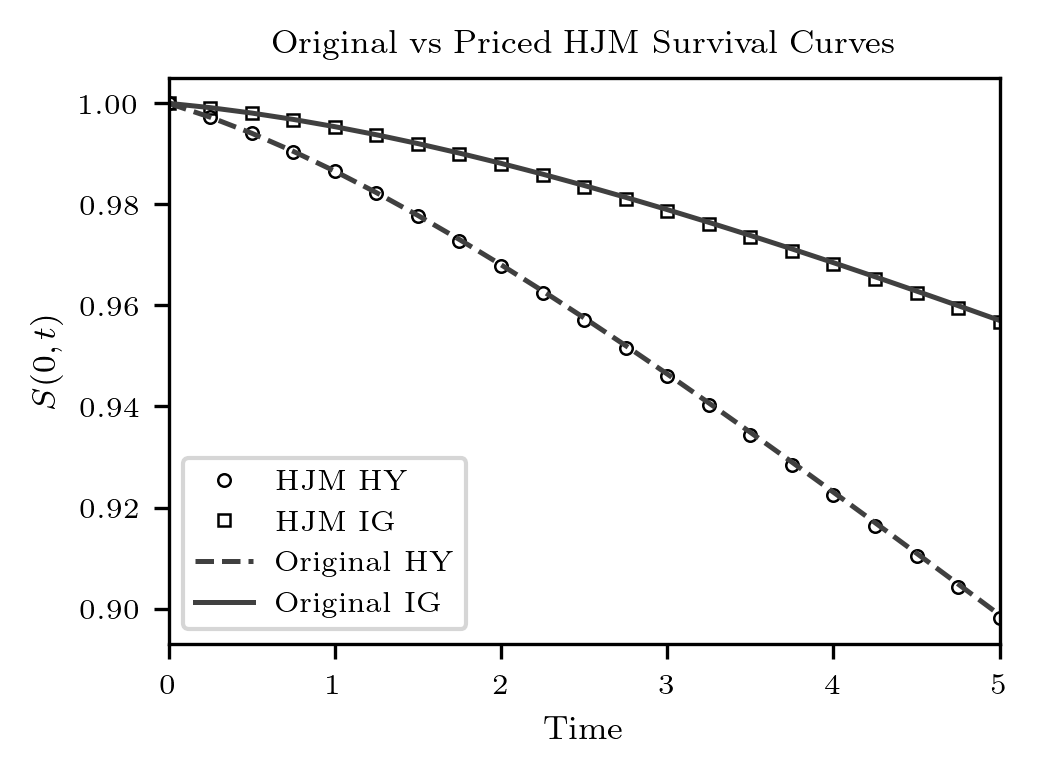

In [28]:
# Vectorised version
# You can reprice the curve using this implementation, but not price options. 
# This implementation materializes large path matrices and is memory intensive.
# Will refactor to use nested for loops and make it pathwise

import numpy as np
import matplotlib.pyplot as plt 

from fig_style import use_ieee_style, new_figure, save_figure

use_ieee_style(single_column=False, height_factor=0.9, use_tex=True)

np.random.seed(0) 
n = 100000

# 3m increments, 5y total time
deltat = 3/12
startTime = 0
endTime = 5
ti = np.arange(startTime, endTime + deltat, deltat)

# Recovery = 0.4 # Recovery Rate
# # cashflows
# Notional = 100
# couponRate   = 0.03 # per coupon, 6% per annum 

# # Coupon dates (semiannual)
# couponIndices  = np.arange(2, len(ti), 2) # increment is 3m, so coupons paid every 2 periods 
# # Build cashflow vector
# coupons = np.zeros(ti.shape)
# coupons[couponIndices] = couponRate 
# couponMatrix = np.tile(coupons,(n,1))

# # For the range accrual condition
# upperBarrier = 150/10000 # in bps
# lowerBarrier = 0

# Discount Factors
a_r = 0.02
b_r = 0.02
c_r = 0.35

D0 = lambda t : np.exp(-a_r*t - (b_r/c_r)*(1-np.exp(-c_r*t)) )
DiscountFactors = D0(ti)

# Investment Grade Parameters
a_h_ig = 0.015
b_h_ig = -0.012
c_h_ig = 0.3 
sigma_h_ig = 0.025 

S0_ig = lambda t : np.exp(-a_h_ig*t - (b_h_ig/c_h_ig)*(1-np.exp(-c_h_ig*t)) )
survivalProbsIG = S0_ig(ti)

# High Yield Parameters
a_h_hy = 0.03
b_h_hy = -0.02
c_h_hy = 0.4
sigma_h_hy = 0.05

S0_hy = lambda t : np.exp(-a_h_hy*t - (b_h_hy/c_h_hy)*(1-np.exp(-c_h_hy*t)) )
survivalProbsHY = S0_hy(ti)

# plt.plot(ti,survivalProbsIG,label = "IG")
# plt.plot(ti,survivalProbsHY,label = "HY")
# plt.legend()
# plt.title("Survival Probability S(0,t)")
# plt.show()

sigma_hat_hy = lambda t1, t2 : sigma_h_hy * np.exp(-c_h_hy * (t2 - t1))
sigma_hat_ig = lambda t1, t2 : sigma_h_ig * np.exp(-c_h_ig * (t2 - t1))

#  Intial Survival Probability Curve and Forward Hazard Curve
ForwardHazardsHY = -np.log(survivalProbsHY[1:] / survivalProbsHY[:-1]) / deltat
ForwardHazardsIG = -np.log(survivalProbsIG[1:] / survivalProbsIG[:-1]) / deltat


# Discrete HJM algorithm
accumHazardsIG = np.ones(n)
accumHazardsHY = np.ones(n)
N = len(ti) - 1
M = N

pathwiseSurvivalIG = np.zeros((n, M))
pathwiseSurvivalHY = np.zeros((n, M))

# pathwiseSpreads = np.zeros((n, M))
FWD_HY = np.tile(ForwardHazardsHY, (n, 1))
FWD_IG = np.tile(ForwardHazardsIG, (n, 1))
# columnVector = np.ones((n,1))

for ix in range(M): 
    # The diagonal entries of the forward curve are the instantaneous hazard rates.
    hazardsIG = FWD_IG[:, ix]
    hazardsHY = FWD_HY[:, ix]

    # pathwiseSpreads[:,ix] = np.maximum(hazards,0) * (1-Recovery) # clip the hazards to prevent negative spreads
    # Survival update
    accumHazardsIG *= np.exp(-hazardsIG * deltat)
    accumHazardsHY *= np.exp(-hazardsHY * deltat)

    # This is the forward curve evolution part
    if ix < N - 1:
        ti_min1 = ti[ix]
        tj = ti[ix+1:-1]

        sigma_j_hy = sigma_hat_hy(ti_min1 * np.ones_like(tj), tj)
        sigma_j_ig = sigma_hat_ig(ti_min1 * np.ones_like(tj), tj)

        ws1_ig = np.cumsum(sigma_j_ig * deltat)**2
        ws1_hy = np.cumsum(sigma_j_hy * deltat)**2

        ws2_ig = np.concatenate(([0], np.cumsum(sigma_j_ig[:-1] * deltat)**2))
        ws2_hy = np.concatenate(([0], np.cumsum(sigma_j_hy[:-1] * deltat)**2))

        mu_j_ig =  (ws1_ig - ws2_ig) / (2*deltat)
        mu_j_hy =  (ws1_hy - ws2_hy) / (2*deltat)


        Zi = np.random.randn(n)

        FWD_IG[:, ix+1:] += mu_j_ig * deltat + sigma_j_ig * np.sqrt(deltat) * Zi[:, None]
        FWD_HY[:, ix+1:] += mu_j_hy * deltat + sigma_j_hy * np.sqrt(deltat) * Zi[:, None]


    pathwiseSurvivalIG[:, ix] = accumHazardsIG
    pathwiseSurvivalHY[:, ix] = accumHazardsHY


pathwiseSurvivalFullIG = np.concatenate([np.ones((n,1)),pathwiseSurvivalIG],axis = 1)
pathwiseSurvivalFullHY = np.concatenate([np.ones((n,1)),pathwiseSurvivalHY],axis = 1)

hjmSurvivalProbabilitiesIG =np.mean(pathwiseSurvivalFullIG, axis=0)
hjmSurvivalProbabilitiesHY =np.mean(pathwiseSurvivalFullHY, axis=0)

# These matrix allocations dominate memory usage.
# RangeAccrualCondtion = np.mean((pathwiseSpreads >= lowerBarrier) & (pathwiseSpreads < upperBarrier),axis = 1)[:, None]
# RedemptionPayment    = (Notional * RangeAccrualCondtion * DiscountFactors[-1])[:, None] # n x 1
# CouponPayment        = np.sum(Notional * couponMatrix * pathwiseSurvivalFull * DiscountFactors ,axis = 1)[:, None] # n x 1
# RecoveryPayment      = np.sum(Notional * Recovery * DiscountFactors[1:] * (pathwiseSurvivalFull[:,:-1] - pathwiseSurvivalFull[:,1:]), axis=1)[:, None] # n x 1
# pathwisePV = RedemptionPayment + CouponPayment + Recovery
# PV = np.mean(pathwisePV)
# SE = np.std(pathwisePV)/np.sqrt(n)
# print(f'The PV {PV} and the Standard Error is {SE}')

fig, ax = new_figure(single_column=True, height_factor=0.75)

ax.plot(ti, hjmSurvivalProbabilitiesHY,
        label="HJM HY",
        linestyle="none",
        marker="o",
        markersize=3,
        markerfacecolor="none",
        markeredgecolor="black",
        markeredgewidth=0.6)

ax.plot(ti, hjmSurvivalProbabilitiesIG,
        label="HJM IG",
        linestyle="none",
        marker="s",
        markersize=3,
        markerfacecolor="none",
        markeredgecolor="black",
        markeredgewidth=0.6)

ax.plot(ti, survivalProbsHY, 
        label="Original HY", 
        linewidth=1.2, 
        color="0.25", 
        linestyle="--")

ax.plot(ti, survivalProbsIG, 
        label="Original IG", 
        linewidth=1.2, 
        color="0.25", 
        linestyle="-")

ax.set_title("Original vs Priced HJM Survival Curves")
ax.set_xlabel("Time")
ax.set_ylabel("$S(0,t)$")
# ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best", frameon=True)

# X axis tight
ax.set_xlim(ti.min(), ti.max())

save_figure(fig, "orig-vs-hjm-survival.pdf")
plt.show()
